In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
from sklearn import linear_model
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
Machine learning is a powerful tool for approximating complex functions from data. Let's consider a scenario where we have a dataset consisting of pairs of feature variables $\mathbf{X}$ and target variable $y$. Our goal is to learn the unknown function $F(\mathbf{X})$ that maps features to targets. We have:
$$y = F(\mathbf{X})$$

In machine learning, we often represent our learned function $f$ as a model with parameters $\theta$. The purpose of training a machine learning model is to learn these parameters $\theta$ and ultimately approximate the true relationship $F$ between the features and the target. When our model is trained, we refer to the output as 'predicted values' $\hat{y}$, not to be mistaken with the actual values $y$. We have:

$$ \hat{y} = f(\mathbf{X}; \theta)$$

Feature variables, also known as attributes or predictor variables capture different aspects or characteristics of the data that we believe are relevant for predicting the target variable. For example, in a dataset of housing prices, feature variables could include square footage, number of bedrooms, location, etc. These features help us build a model that can predict the price of a house based on its characteristics.

To evaluate the performance of our model, we typically split our dataset into two subsets: training data and testing data. The training data is used to train the model (learn parameters $\theta$), while the testing data is used to evaluate how well the model generalizes to new unseen observations. During training the model musn't know anything about the testing data. 

## Regression
For regression machine learning problems, we treat $y,\hat{y}$ as a continuous variable.

#### Linear Regression
Linear regression is simple machine learning model which involves the treatment of $f$ as a linear combination of the features $x$. Therefore, we may train the model to learn the coefficients $\theta$ of the function:

$$\hat{y} = f(\mathbf{X}; \theta) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n$$

Here, $\theta_0, \theta_1, \dots, \theta_n$ are the parameters of the model, and $x_1, x_2, \dots, x_n$ are the feature variables.
#### Linear Regression Example: 
In the following example we will use linear regression to predict a quantitative measure of diabetes disease progression based on age, sex, bmi, blood pressure and six blood serum measurements s1 to s6 in sklearn's diabetes dataset.

In [4]:
diabetes = load_diabetes()
print(f"Number of data samples: {diabetes.target.shape[0]}")
print(f"Number of potential attribute variables: {diabetes.data.shape[1]}")
print(f"Feature variable names: {diabetes.feature_names}")

Number of data samples: 442
Number of potential attribute variables: 10
Feature variable names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


Number of training samples: 265
Number of testing samples: 177
Learned parameters 𝜃_0: 153.06667237581786, 𝜃_1: 734.4964078049923


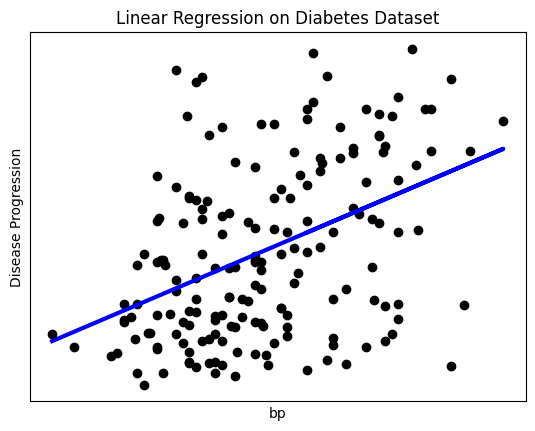

In [5]:
def single_variable_linear_regression(dataset, predictor_label):
    i = dataset.feature_names.index(predictor_label)
    X = dataset.data[:,i]
    y = dataset.target

    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size = 0.4, random_state=5)
    print(f"Number of training samples: {Xtr.shape[0]}")
    print(f"Number of testing samples: {Xte.shape[0]}")

    # Create linear regression object
    f = linear_model.LinearRegression()
    # Train the model using the training sets
    f.fit(Xtr.reshape(-1,1), ytr)

    yte_predicted = f.predict(Xte.reshape(-1,1))
    ytr_predicted = f.predict(Xtr.reshape(-1,1))

    # Learned parameters
    print(f"Learned parameters 𝜃_0: {f.intercept_}, 𝜃_1: {f.coef_[0]}")

    plt.scatter(Xte, yte, color="black")
    plt.plot(Xte, yte_predicted, color="blue", linewidth=3)
    plt.xlabel(predictor_label)
    plt.ylabel("Disease Progression")
    plt.title("Linear Regression on Diabetes Dataset")
    plt.xticks(())
    plt.yticks(())
    plt.show()
    
    return ytr, yte, ytr_predicted, yte_predicted
    
# Feature variable options:
#age age in years
#sex
#bmi body mass index
#bp average blood pressure
#s1 tc, total serum cholesterol
#s2 ldl, low-density lipoproteins
#s3 hdl, high-density lipoproteins
#s4 tch, total cholesterol / HDL
#s5 ltg, possibly log of serum triglycerides level
#s6 glu, blood sugar level

ytr, yte, ytr_pred, yte_pred = single_variable_linear_regression(diabetes, 'bp')


### Regression Model Evaluation

To evaluate our model we measure the difference between predicted $\hat{y}$ and actual $y$ target values. There are many ways to do this depending on the prediction task. Here are some common examples:

##### Mean squared error (MSE) 
$$MSE = \frac{1}{n} \sum_{}^{n}(y - \hat{y})^2$$
##### Mean absolute error (MAE)
$$MAE = \frac{1}{n} \sum_{}^{n}|y - \hat{y}|$$
##### Mean absolute percentage error (MAPE)
$$MAPE = \frac{100\%}{n} \sum_{}^{n}\left|\frac{y - \hat{y}}{y}\right|$$
##### Residual mean squared error (RMSE)
$$RMSE = \sqrt{\frac{\sum_{}^{n}(y - \hat{y})^2}{n}}$$

In [7]:
regression_metrics = [mean_squared_error, mean_absolute_error, mean_absolute_percentage_error]
for met in regression_metrics:
    print(f"Test {met.__name__}: %.2f" % met(yte, yte_pred))
    print(f"Train {met.__name__}: %.2f" % met(ytr, ytr_pred))

print(f"Test RMSE: %.2f" % mean_squared_error(yte, yte_pred, squared=False))
print(f"Train RMSE: %.2f" % mean_squared_error(ytr, ytr_pred, squared=False))

Test mean_squared_error: 5152.24
Train mean_squared_error: 4524.48
Test mean_absolute_error: 58.77
Train mean_absolute_error: 55.98
Test mean_absolute_percentage_error: 0.57
Train mean_absolute_percentage_error: 0.52
Test RMSE: 71.78
Train RMSE: 67.26


## Classification

The goal of classification is to predict the category or class label $\hat{y}$ based on input data $X$. We now treat $y$ and $\hat{y}$ as discrete class labels, e.g animals (cat, dog, bird, fish). 

There are many different ways to formalize machine learning classification. Here we only adopt a softmax-based formalization.

We may still assume that the training process learns the parameters $\theta$ for the function $f(\textbf{X};\theta)$, only now $f: \textbf{X} \rightarrow \textbf{R}^{m}$ where there are $m$ possible class labels and we introduce additional post-processing operations to map $f$ to a class label $\hat{y}$. 

We may denote $\textbf{z}=(z_1,z_2,..,z_m)=f(\textbf{X};\theta)$. Each $z_i$ represents the 'logits' which are raw unormalized scores. Logits have some positive correlation with the probability of $\hat{y}$ belonging to class $i$. We apply the softmax function to transform these logits into a probability distribution.
$$ softmax(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{m}e^{z_j}}$$
After calculating the softmax probabilities we select the class with the highest probability as our predicted class label:
$$ \hat{y} = argmax_i(softmax(z_i))$$

#### Multi-layer Perceptron (MLP)
This is a type of machine learning algorithm which uses a neural network to either perform regression or classification tasks. We will go into more depth on neural networks in future lessons.

#### MLP Classification Example:
We use a multi-layer-perceptron (MLP) neural network architecture to classify iris flower species based on sepal and petal proportions in sklearn's iris dataset.

![Alt Text](iris_flowers.png)


In [13]:
iris = load_iris()
print(f"Number of data samples: {iris.target.shape[0]}")
print(f"Number of potential feature variables: {iris.data.shape[1]}")
print(f"Feature variable names: {iris.feature_names}")
print(f"Target class labels: {iris.target_names}")

np.random.seed(1)

def add_noise(data, noise_level):
    feature_ranges = np.ptp(data, axis=0)  # Peak-to-peak (maximum - minimum) along the given axis
    # Generate random noise with the same shape as the dataset
    noise = np.random.uniform(low=-noise_level * feature_ranges, high=noise_level * feature_ranges, size=data.shape)

    # Add noise to the dataset
    iris.data = iris.data + noise
    return iris.data

iris.data = add_noise(iris.data, 0.9) #0.9

Number of data samples: 150
Number of potential feature variables: 4
Feature variable names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target class labels: ['setosa' 'versicolor' 'virginica']


Number of training samples: 120
Number of testing samples: 30
Accuracy: 0.7


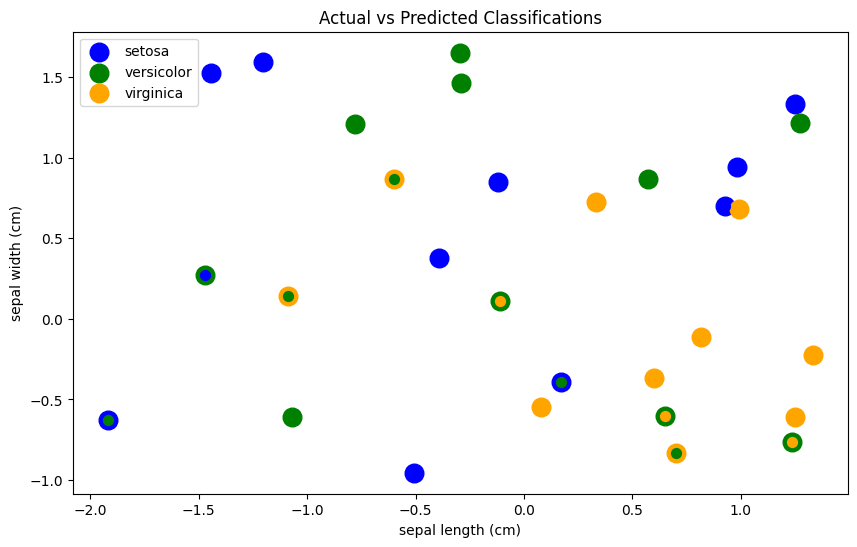

In [15]:
X, y = iris.data, iris.target
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
#stratify ensures that relative class frequencies are approximately preserved in each split.
print(f"Number of training samples: {Xtr.shape[0]}")
print(f"Number of testing samples: {Xte.shape[0]}")

scaler = StandardScaler()
Xtr = scaler.fit_transform(Xtr)
Xte = scaler.transform(Xte)

#balanced model
clf = MLPClassifier(hidden_layer_sizes=(45,), activation='relu', solver='adam', max_iter=1000, random_state=42)

#overly complex model learns to overfit the noise
#clf = MLPClassifier(hidden_layer_sizes=(200,), activation='relu', solver='adam', max_iter=1000, random_state=42)

#overly simple model learn to underfit
#clf = MLPClassifier(hidden_layer_sizes=(1,), activation='relu', solver='adam', max_iter=1000, random_state=42)

clf.fit(Xtr, ytr)

# Predict the class labels for the testing set
yte_pred = clf.predict(Xte)
ytr_pred = clf.predict(Xtr)

# Calculate the accuracy of the classifier
accuracy = accuracy_score(yte, yte_pred)
print("Accuracy:", accuracy)
feature_names = iris.feature_names
x_feature_index = 0  # Index of the first feature
y_feature_index = 1  # Index of the second feature
# Plot the data
cmap = ['blue', 'green', 'orange']
plt.figure(figsize=(10, 6))
#plot true class labels as larger circles
for class_label in np.unique(y):
    X_class = Xte[yte == class_label]
    plt.scatter(X_class[:, x_feature_index], X_class[:, y_feature_index], label=iris.target_names[class_label], color=cmap[class_label], s=180)

# plot the predicted class labels as smaller inner circles
for class_label in np.unique(y):
    X_class = Xte[yte_pred == class_label]
    plt.scatter(X_class[:, x_feature_index], X_class[:, y_feature_index], color=cmap[class_label], s=50)

plt.xlabel(feature_names[x_feature_index])
plt.ylabel(feature_names[y_feature_index])
plt.title('Actual vs Predicted Classifications')
plt.legend()
plt.show()

### Classification Model Evaluation

Explanation of classification evaluation metrics is best done using a binary classification problem.
Here are some recommended resources:
https://medium.com/@impythonprogrammer/evaluation-metrics-for-classification-fc770511052d

https://www.youtube.com/watch?v=vP06aMoz4v8

https://www.youtube.com/watch?v=Kdsp6soqA7o


![Alt Text](confusion_matrix_2.png)

#### Airport Security Analogy. 
Positive = this passenger is a potential threat, flag for extra screening.

* Accuracy: overall what fraction of passengers did we predict correctly?

What if classes are imbalanced or real-world costs are imbalanced (i.e. consequences of a FN are more significant than a FP)?

* Precision (positive predictive value (PPV)): when we flag someone, how often are we right they're a threat? High precision = few innocent people are hassled (low false alarms).
* Recall (sensitivity): of all actual threats, how many did we catch? High recall = few threats slip through (low misses).
* F1 $= \dfrac{2 \times (precision \times recall)}{precision + recall}$ Harmonic mean of precision and recall. A single score which rewards us when we have a high precision and recall. How good is the security checkpoint at catching threats without harassing too many people? Robust against class imbalance but not real-world cost imbalance. 
    * Precision = 0.9, Recall = 0.1 --> F1 = 0.18
    * Precision = 0.1, Recall = 0.9 --> F1 = 0.18
    * Precision = 0.7, Recall = 0.7 --> F1 = 0.7
    
#### Applying to Multi-class Classification

For each class $i$, treat it as "positive" and all other classes as "negative" (i.e. $TP_i$ is true $i$ predicted $i$), compute per-class metrics (i.e. $accuracy_i$, $precision_i$), average metrics over classes gives us macro accuracy, precision, ...

Test accuracy: 0.7666666666666667
Train accuracy: 0.8583333333333333

Test precision: 0.7646464646464647
Train precision: 0.8586668751302898

Test recall: 0.7666666666666666
Train recall: 0.8583333333333334

Test f1 score: 0.7644945697577277
Train f1 score: 0.8584166796895348


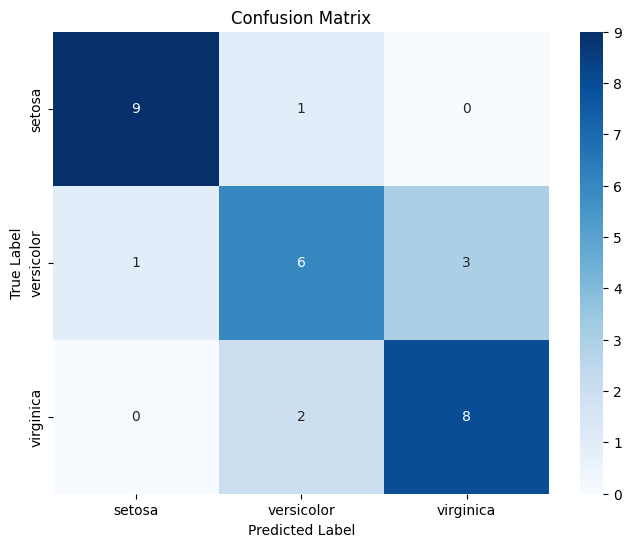

In [10]:
print(f"Test accuracy: {accuracy_score(yte, yte_pred)}")
print(f"Train accuracy: {accuracy_score(ytr, ytr_pred)}\n")

print(f"Test precision: {precision_score(yte, yte_pred, average='macro')}")
print(f"Train precision: {precision_score(ytr, ytr_pred, average='macro')}\n")

print(f"Test recall: {recall_score(yte, yte_pred, average='macro')}")  
print(f"Train recall: {recall_score(ytr, ytr_pred, average='macro')}\n")

print(f"Test f1 score: {f1_score(yte, yte_pred, average='macro')}")  
print(f"Train f1 score: {f1_score(ytr, ytr_pred, average='macro')}")

conf_matrix = confusion_matrix(yte, yte_pred)
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
#shows us that recall for versicolor is higher. 
plt.show()

## Bias-Variance Trade-Off

The bias-variance trade-off describes two competing sources of prediction error.

##### Bias: 
the difference between the predicted values of our model and the actual values. 

##### Variance: 
the 'spread' of the model's predictions. 
![Alt Text](bias_variance.png)



Bias is error from an overly simple model or overly restrictive training setup: the model does not learn enough 'facts' to capture the true relationship in the data, so it makes systematic mistakes. A training method should ensure **low bias** to prevent **underfitting**, where both training and test performance are poor. In the linear regression example, a straight line fitted to clearly curved data is a typical high-bias (underfitting) outcome.

Variance is error from an overly flexible/complex model that is too sensitive to the particular training set: the model learns too many irrelevant 'facts' in the training data such that small changes in the training data can produce noticeably different fitted models. **High variance** leads to **overfitting**, where training error becomes very low but performance on unseen test data degrades. In the regression and classification illustrations, the overly “wiggly” regression curve or highly irregular decision boundary fits noise and idiosyncrasies in the training samples rather than the underlying pattern.

![Alt Text](bias_variance_tradeoff_2.jpg)


The goal of model selection and training is to minimise generalisation error (error on unseen data) by choosing appropriate model capacity/complexity and training objectives (which control how many 'facts' the model learns about the training data). The following graph illustrates the optimal region between the overfitting and underfitting zones. To avoid confusion, think of the x-axis representing how many 'facts' the model learns about the training data (increasing model complexity is one of many ways to increase the number of facts that a model learns about the training data). On the y-axis, error refers to any notion of poor performance: e.g high variance, high bias, the difference between predicted vs actual testing targets.

When we increase the number of 'facts' which the model learns about the training data (e.g by increasing model complexity) this typically reduces bias but increases variance, while reduucing the number of 'facts' typically reduces variance at the cost of higher bias.

Irreducible error refers to part of the test error which you cannot drive to zero no matter how good the model is (e.g. noise from incorrect target labels, missing feature variables, learning task is underdetermined).

![Alt Text](bias_variance_tradeoff.jpg)


Further resources on bias-variance tradeoff: 

https://www.geeksforgeeks.org/ml-bias-variance-trade-off/?ref=leftbar-rightbar

https://www.youtube.com/watch?v=EuBBz3bI-aA